# Progetto del corso - Introduzione alla Data Science e al pensiero computazionale - a.a. 2025/2026

# Membri del gruppo numero 12

Il gruppo numero 12 è composto da:

*   **Nicoletta Aloisi:** matricola 1216124, email nicoletta.aloisi@studio.unibo.it
*   **Erika Avdiaj:** matricola 1226030, email erika.avdiaj@studio.unibo.it
*   **Giannalisa Romeo:** matricola 1216078, email giannalisa.romeo@studio.unibo.it

# Materiale del progetto

Il materiale del progetto è disponibile sul sito del corso e contiene i seguenti dataset:

* *Bank_Marketing*
* *Credit_Card_Default*
* *Customer_Churn*
* *Employee_Attrition* (**noi abbiamo scelto questo dataset**: dobbiamo predire l'abbandono dei dipendenti; variabile target: Attrition)
* *Online_Shoppers*


# Fase 1 - Setup Progetto e repository Github
* Struttura cartelle: data/ , notebooks/ , figures/ , report/ , README.md
* README.md con: descrizione progetto, descrizione dataset, obiettivo, modelli usati, istruzioni d'esecuzione, membri del gruppo
* Requisiti Git: ≥10 commit, messaggi significativi, almeno 1 branch per membro, almeno 1 merge

# Fase 2 - Descrizione e comprensione del dataset
* Capire struttura, distribuzioni, qualità, limiti, possibili problemi
* Minimo: 8 domande/ipotesi, 5 statistiche descrittive, 3 riflessioni critiche (es. class imbalance, outlier, feature correlate, dati mancanti, feature sospette)

###**Struttura del dataset**

**Preparazione dell'ambiente**

Prima di iniziare questa parte dobbiamo preparare l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**.

In [12]:
# Pandas
import pandas as pd
import numpy as np

# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn import svm, tree
from sklearn.metrics import *

In [84]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)  # come nel notebook precedente, per riproducibilità degli esempi
# genera dei numeri pseudo casuali, partendo dal seme 42

In [13]:
emp = pd.read_csv("sample_data/Employee_Attrition.csv", sep=",")

In [14]:
emp.head()  #le prime 5 righe del dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [15]:
emp.shape   #quante righe e colonne

(1470, 35)

Il dataset di training include 1470 osservazioni e 35 variabili.

In [16]:
emp.dtypes   #tipo di dato per ogni colonna

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


L'analisi dei tipi di dato mostra che le variabili del dataset sono numeriche intere o categoriche.

In [17]:
emp.isnull().sum()    #quanti valori mancanti

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Non sono presenti valori mancanti nel dataset.

In [18]:
emp.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0


In [19]:
categorical_cols = emp.select_dtypes(include='object').columns.tolist() #variabili categoriche
categorical_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [20]:
# Variabili con due valori distinti
two_value_cols = [col for col in emp.columns if emp[col].nunique() == 2]
print("Variabili con due valori:", two_value_cols)

# Variabili realmente binarie (concettualmente dicotomiche)
binary_cols = ['Attrition', 'Gender', 'OverTime']
print("Variabili binarie utili per l'analisi:", binary_cols)


Variabili con due valori: ['Attrition', 'Gender', 'OverTime', 'PerformanceRating']
Variabili binarie utili per l'analisi: ['Attrition', 'Gender', 'OverTime']


In [21]:
emp['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [22]:
(emp['Attrition'].value_counts(normalize=True) * 100).round(2)

,proportion
Attrition,
No,83.88
Yes,16.12


Il dataset **Employee Attrition** è composto da **1470 righe e 35 colonne**, che descrivono diverse caratteristiche dei dipendenti di un’azienda. Le informazioni contenute riguardano:

1. *dati anagrafici*: età (Age), genere (Gender), stato civile (MaritalStatus);

2. *caratteristiche lavorative*: dipartimento (Department), ruolo (JobRole), livello (JobLevel), anni di esperienza totale (TotalWorkingYears), anni nella stessa azienda (YearsAtCompany), anni nel ruolo attuale (YearsInCurrentRole);

3. *variabili retributive*: HourlyRate, DailyRate, MonthlyIncome, PercentSalaryHike;

4. *indicatori di soddisfazione e coinvolgimento*: JobSatisfaction, EnvironmentSatisfaction, JobInvolvement, RelationshipSatisfaction, WorkLifeBalance;

5. *variabili legate alla mobilità*: BusinessTravel, DistanceFromHome;

6. *variabili amministrative*: EmployeeNumber, StockOptionLevel, TrainingTimesLastYear.

Il dataset contiene **26 variabili numeriche e 9 variabili categoriche**.
Tra le variabili numeriche è possibile distinguere:

* *Variabili ordinali* (codificate come numeri ma rappresentano livelli): Education; EnvironmentSatisfaction; JobInvolvement; JobLevel; JobSatisfaction; PerformanceRating; RelationshipSatisfaction; WorkLifeBalance; StockOptionLevel

* *Variabili continue* (vere quantità misurabili): Age; DailyRate; DistanceFromHome; HourlyRate; MonthlyIncome; MonthlyRate; NumCompaniesWorked; PercentSalaryHike; TotalWorkingYears; TrainingTimesLastYear; YearsAtCompany; YearsInCurrentRole; YearsSinceLastPromotion; YearsWithCurrManager; EmployeeNumber; EmployeeCount (costante); StandardHours → (costante)

Alcune variabili del dataset presentano due valori distinti, ma non possono essere considerate **binarie** dal punto di vista concettuale. Ad esempio, PerformanceRating assume i valori 3 e 4 ma rappresenta una scala ordinale; StockOptionLevel può assumere valori da 0 a 3; BusinessTravel e MaritalStatus hanno tre categorie.
Le vere variabili binarie utili per l’analisi sono invece Attrition, Gender e OverTime, che rappresentano effettive condizioni dicotomiche (es. Yes/No, Male/Female). Questa distinzione è importante perché solo le variabili realmente binarie possono essere utilizzate per confronti diretti tra gruppi e per alcune tecniche di modellazione.

Tutte le colonne risultano complete: **non sono presenti valori mancanti**.
Questo semplifica l’analisi, anche se è un elemento insolito nei dataset reali e suggerisce che i dati siano stati pre-puliti.

Si osservano inoltre alcune variabili costanti, come EmployeeCount (sempre = 1), StandardHours (sempre = 80) e Over18 (sempre = “Y”), non apportano informazioni utili e dovrebbero essere rimosse nelle fasi successive.

La variabile target **Attrition** è binaria e presenta un forte sbilanciamento:
**1233 “No” e 237 “Yes”**. La stragrande maggioranza dei dipendenti ha continuato a lavorare in azienda (84%). Il 16% dei dipendenti, invece, ha lasciato il proprio posto di lavoro.
Questo squilibrio dovrà essere considerato con attenzione nelle fasi di analisi e modellazione.

#5 statistiche descrittive

In [23]:
emp[["Age", "DistanceFromHome", "MonthlyIncome", "TotalWorkingYears", "JobSatisfaction"]].describe().round(2)
#eliminare?

,Age,DistanceFromHome,MonthlyIncome,TotalWorkingYears,JobSatisfaction
count,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,9.19,6502.93,11.28,2.73
std,9.14,8.11,4707.96,7.78,1.10
min,18.00,1.00,1009.00,0.00,1.00
25%,30.00,2.00,2911.00,6.00,2.00
50%,36.00,7.00,4919.00,10.00,3.00
75%,43.00,14.00,8379.00,15.00,4.00
max,60.00,29.00,19999.00,40.00,4.00


**AGGIUNGERE COLONNE PIù RILEVANTI**

Dall'analisi delle principali statistiche, si possono osservare:
1. Age: mediana (36 anni) e media (36,9 anni) risultano simmetriche. La maggior parte dei dipendenti (il 50%) è tra 30 e 43 anni.

2. Distance From Home: la media (9,2) è maggiore della mediana (7), suggerendo che alcuni dipendenti (outlier) abitino lontano dal luogo di lavoro.

3. Monthly Income: la media (6503) è molto maggiore della mediana (4919), suggerendo una distribuzione asimmetrice verso destra, con pochi dipendenti con stipendi elevati (outlier)  che alzano inevitabimlente la media.

4. Total Working Years: la media indica che generalmente gli anni di lavoro complessivi corrispondano a 11,3 anni; da confrontare con Years At Company: la media di 7 anni e la mediana di 5 anni indicano che molti dipendenti lavorano nell'azienda attuale da relativamente poco tempo; solo una minoranza è presente da decenni.

5. Job Satisfaction ha una media di 2,7 su 4, stazionandosi su un livello medio - vedremo se la soddisfazione lavorativa influenza o meno l'abbandono dell'azienda.

In questa sezione vengono analizzate le principali statistiche descrittive delle variabili ordinali e continue del dataset, con l’obiettivo di valutare la loro variabilità, il range e il potenziale contenuto informativo.

STATISTICHE DELLE VARIABILI ORDINALI

In [24]:
ordinal_var = [
    'EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction',
    'JobLevel', 'Education', 'WorkLifeBalance', 'JobInvolvement'
]
emp[ordinal_var].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.0,3.0,4.0,4.0
JobSatisfaction,1470.0,2.73,1.10,1.0,2.0,3.0,4.0,4.0
RelationshipSatisfaction,1470.0,2.71,1.08,1.0,2.0,3.0,4.0,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.0,2.0,3.0,5.0
Education,1470.0,2.91,1.02,1.0,2.0,3.0,4.0,5.0
WorkLifeBalance,1470.0,2.76,0.71,1.0,2.0,3.0,3.0,4.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.0,3.0,3.0,4.0


**ANALISI DELLE STATISTICHE DESCRITTIVE DELLE VARIABILI ORDINALI**
1. **EnvironmentSatisfaction**:
La variabile mostra una buona variabilità (std = 1.09) e un range completo 1-4.
La mediana è 3, con quartili 2-4, la maggior parte dei dipendenti riporta livelli medi o alti di soddisfazione ambientale.
La dispersione suggerisce differenze reali tra individui, rendendola una variabile potenzialmente informativa.

2. **JobSatisfaction**:
Distribuzione molto simile a EnvironmentSatisfaction (mean = 2.73, std = 1.10).
La variabilità è ampia e il range copre tutti i livelli 1-4.
La mediana è 3, indicando una soddisfazione lavorativa generalmente moderata.
È una variabile rilevante perché cattura differenze significative nelle percezioni del lavoro.

3. **RelationshipSatisfaction**:
Anche qui la variabilità è elevata (std = 1.08) e il range è completo 1-4.
La mediana è 3, con quartili 2-4, la maggior parte dei dipendenti ha relazioni soddisfacenti con colleghi e supervisori.
La dispersione indica che la qualità delle relazioni interpersonali varia tra individui, rendendola una variabile utile.

4. **JobLevel**:
Insieme ad Education è la variabile con il range più ampio tra le ordinali (1-5) ma rispetto a quest'ultima ha una variabilità più elevata (std = 1.11).
La mediana è 2, con quartili 1-3, la distribuzione è sbilanciata verso livelli più bassi, ma con presenza di livelli più alti.
La struttura dei livelli gerarchici è informativa e riflette differenze sostanziali nei ruoli.

5. **Education**:
La variabilità è moderata (std = 1.02) e il range copre tutti i livelli 1-5.
La mediana è 3, con quartili 2-4, la maggior parte dei dipendenti ha un livello di istruzione medio-alto.
La variabilità è sufficiente per considerarla una variabile informativa, anche se meno forte rispetto alle variabili di soddisfazione.

6. **WorkLifeBalance**:
Variabilità più contenuta (std = 0.71) e range 1-4.
La mediana è 3, con quartili 2-3, la distribuzione è più concentrata rispetto alle altre variabili ordinali.
È moderatamente informativa, ma la dispersione ridotta suggerisce differenze meno marcate tra individui.

7. **JobInvolvement**:
Variabilità simile a WorkLifeBalance (std = 0.71) e range 1-4.
La mediana è 3, con quartili 2-3, la maggior parte dei dipendenti mostra un coinvolgimento lavorativo medio.
La variabilità limitata la rende una variabile moderatamente significativa.


Le variabili ordinali con variabilità più ridotta, come PerformanceRating e StockOptionLevel, sono state comunque esaminate, ma presentano distribuzioni molto concentrate e range limitati. Questa scarsa dispersione suggerisce differenze minime tra i dipendenti, rendendole meno utili ai fini dell’analisi rispetto alle altre variabili ordinali più informative.

STATISTICHE DELLE VARIABILI CONTINUE

In [25]:
continuous_var = [
    'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsWithCurrManager', 'YearsSinceLastPromotion',
    'Age', 'DistanceFromHome', 'NumCompaniesWorked'
]
emp[continuous_var].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
MonthlyIncome,1470.0,6502.93,4707.96,1009.0,2911.0,4919.0,8379.0,19999.0
TotalWorkingYears,1470.0,11.28,7.78,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.01,6.13,0.0,3.0,5.0,9.0,40.0
YearsInCurrentRole,1470.0,4.23,3.62,0.0,2.0,3.0,7.0,18.0
YearsWithCurrManager,1470.0,4.12,3.57,0.0,2.0,3.0,7.0,17.0
YearsSinceLastPromotion,1470.0,2.19,3.22,0.0,0.0,1.0,3.0,15.0
Age,1470.0,36.92,9.14,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.0,7.0,14.0,29.0
NumCompaniesWorked,1470.0,2.69,2.50,0.0,1.0,2.0,4.0,9.0


**ANALISI DELLE STATISTICHE DESCRITTIVE DELLE VARIABILI CONTINUE**

1. **MonthlyIncome**:
La variabile presenta un’elevata variabilità (std = 4707.96) e un range molto ampio (1009-19999).
I quartili mostrano una forte dispersione salariale tra i dipendenti, indicando differenze sostanziali nelle posizioni e nei livelli retributivi.
Questa ampiezza rende la variabile particolarmente informativa.

2. **TotalWorkingYears**:
La variabilità è elevata (std = 7.78) e il range copre l’intero arco della carriera (0-40 anni).
La mediana è 10 anni, con quartili 6-15, la distribuzione riflette una forza lavoro eterogenea per esperienza.
È una variabile molto significativa perché cattura differenze strutturali nei percorsi professionali.

3. **YearsAtCompany**:
La variabilità è ampia (std = 6.13) e il range va da 0 a 40 anni.
La mediana è 5 anni, con quartili 3-9, la permanenza aziendale varia notevolmente tra i dipendenti.
La dispersione elevata la rende una variabile informativa per comprendere la stabilità interna.

4. **YearsInCurrentRole**:
La variabilità è consistente (std = 3.62) e il range va da 0 a 18 anni.
La mediana è 3 anni, con quartili 2-7, la permanenza nel ruolo mostra differenze significative tra individui.
È una variabile rilevante perché riflette la continuità e la maturazione nel ruolo attuale.

5. **YearsWithCurrManager**:
La variabilità è simile a YearsInCurrentRole (std = 3.57) e il range è ampio (0-17).
La mediana è 3 anni, con quartili 2-7, la relazione con il manager varia sensibilmente tra dipendenti.
La dispersione suggerisce che la stabilità del rapporto gerarchico è un elemento informativo.

6. **YearsSinceLastPromotion**:
La variabilità è moderata (std = 3.22) ma il range è ampio (0-15).
La mediana è 1 anno, con quartili 0-3, molti dipendenti non hanno ricevuto promozioni recenti.
La variabilità rende la variabile utile per cogliere differenze nei percorsi di crescita interna.

7. **Age**:
La variabilità è elevata (std = 9.14) e il range copre l’intero ciclo lavorativo (18-60 anni).
La mediana è 36 anni, con quartili 30-43, la distribuzione mostra una forza lavoro diversificata per età.
È una variabile moderatamente significativa, utile per contestualizzare l’esperienza.

8. **DistanceFromHome**:
La variabilità è ampia (std = 8.11) e il range va da 1 a 29 km.
La mediana è 7 km, con quartili 2-14, la distanza dal luogo di lavoro varia sensibilmente tra dipendenti.
È una variabile moderatamente informativa, potenzialmente legata a fattori logistici.

9. **NumCompaniesWorked**:
La variabilità è moderata (std = 2.50) e il range va da 0 a 9.
La mediana è 2, con quartili 1-4: la storia lavorativa precedente è eterogenea ma non estremamente dispersa.
È una variabile moderatamente significativa, utile per comprendere la mobilità professionale.

Alcune variabili continue, come DailyRate, HourlyRate, MonthlyRate, PercentSalaryHike, TrainingTimesLastYear ed EmployeeNumber, sono state comunque esaminate, ma presentano una variabilità ridotta o un contenuto informativo limitato. La loro distribuzione risulta molto concentrata oppure non riflette aspetti sostanziali della condizione lavorativa dei dipendenti, rendendole meno utili rispetto alle variabili più rilevanti considerate nell’analisi.


Nel complesso, dall’analisi descrittiva emergono come più significative le variabili che presentano maggiore variabilità e un contenuto informativo sostanziale.

Tra le variabili continue:
* MonthlyIncome;
* TotalWorkingYears;
* YearsAtCompany;
* YearsInCurrentRole;
* YearsWithCurrManager;
* YearsSinceLastPromotion.

Tra le variabili ordinali:
* EnvironmentSatisfaction;
* JobSatisfaction;
* RelationshipSatisfaction;
* JobLevel;
* Education.

Questi elementi mostrano differenze rilevanti tra i dipendenti e risultano quindi particolarmente utili per comprendere la struttura e l’eterogeneità della forza lavoro analizzata.

Queste statistiche descrittive forniscono una prima comprensione della struttura del dataset e permettono di identificare le variabili che meritano maggiore attenzione nelle fasi successive di analisi esplorativa e modellazione.

#8 domande/ipotesi

*1. I dipendenti che fanno straordinari (Over Time) lasciano più frequentemente l'azienda?*

In [26]:
pd.crosstab(emp['OverTime'], emp['Attrition'], normalize='index').round(4)*100

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


Il 30% dei dipendenti che fanno straordinari lascia l'azienda; mentre, per coloro che non svolgono straordinari, solo il 10% lascia l'azienda. Dunque, gli straordinari possono influire nell'incentivare ad abbandonare l'azienda.

*1.1. Lavorare in uno specifico dipartimento, combinato con le ore di straordinario, influisce sull'abbandono dei dipendenti?*

**TABELLA INCROCIATA TRA DEPARTMENT, MONTHLY INCOME, ATTRITION**

INVECE DI MONTHLYINCOME ho usato OVERTIME perchè CI SONO RISULTATI PIù NETTI

In [27]:
pd.crosstab(
    [emp['Department'], emp['OverTime']],
    emp['Attrition'],
    normalize='index'
).round(4)*100

Attrition                           No    Yes
Department             OverTime              
Human Resources        No        84.78  15.22
                       Yes       70.59  29.41
Research & Development No        91.45   8.55
                       Yes       72.69  27.31
Sales                  No        86.16  13.84
                       Yes       62.50  37.50

La tabella mostra che l’overtime è associato a un aumento dell’attrition, ma l’intensità dell’effetto varia tra i dipartimenti.

* **Human Resources**: l’overtime aumenta l’attrition in modo moderato (dal 15% al 29%).

* **Research & Development**: l’effetto è molto marcato (dal 9% al 27%), indicando che il dipartimento rimane stabile solo in assenza di straordinari.

* **Sales**: è il dipartimento più sensibile all’overtime, con l’attrition che sale dal 14% al 38%.

In sintesi, i dipartimenti mostrano una diversa sensibilità all’overtime: in HR l’effetto sull’attrition è contenuto, in R&D diventa marcato e in Sales raggiunge i livelli più elevati.

*2. Uno stipendio mensile più basso aumenta la probabilità di Attrition?*

In [28]:
emp.groupby('Attrition')['MonthlyIncome'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.74,4818.21,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.09,3640.21,1009.0,2373.0,3202.0,5916.0,19859.0


Si nota che, i dipendenti che abbandonano l'azienda hanno uno stipendio mediamente più basso rispetto a coloro che rimangono (il 75% dei dipendenti che lasciano l'azienda guadagna 5916 euro al mese vs gli 8834 euro al mese guadagnati da coloro che restano).

*3. I dipendenti più giovani abbandonano più spesso l'azienda?*

In [29]:
emp.groupby('Attrition')['Age'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.56,8.89,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.61,9.69,18.0,28.0,32.0,39.0,58.0


I dipendenti che lasciano l'azienda sono mediamente più giovani (33 anni); mentre coloro che continuano a lavorare hanno mediamente 37 anni. Si potrebbe ipotizzare che i più giovani vogliano fare carriera altrove, magari non avendo ancora un ruolo importante in azienda o uno stipendio ritenuto soddisfacente.


*4. L'età dei dipendenti combinata con lo stipendio mensile aumenta la probabilità di dimissioni?*

In [30]:
#divido lo stipendio mensile in due fasce
emp['IncomeGroup'] = pd.cut(
    emp['MonthlyIncome'],
    bins=[0, 5000, emp['MonthlyIncome'].max()],
    labels=['Reddito ≤ 5.000', 'Reddito > 5.000'],
)

emp['IncomeGroup'].value_counts()


,count
IncomeGroup,
Reddito ≤ 5.000,749
Reddito > 5.000,721


In [31]:
#divido l'età in fasce
emp['AgeGroup'] = pd.cut(
    emp['Age'],
    bins=[17, 30, 40, 50, emp['Age'].max()],
    labels=['≤30', '31-40', '41-50', '51+']
)
emp['AgeGroup'].value_counts().sort_index()
#sort.index mette in ordine le fasce dai più giovani agli anziani

,count
AgeGroup,
≤30,386
31-40,619
41-50,322
51+,143


In [32]:
pd.crosstab(
    [emp['AgeGroup'], emp['IncomeGroup']],
    emp['Attrition'],
    normalize='index' #calcola le percentuali per riga
).round(4) * 100


Attrition                    No    Yes
AgeGroup IncomeGroup                  
≤30      Reddito ≤ 5.000  71.10  28.90
         Reddito > 5.000  85.90  14.10
31-40    Reddito ≤ 5.000  82.33  17.67
         Reddito > 5.000  89.97  10.03
41-50    Reddito ≤ 5.000  86.79  13.21
         Reddito > 5.000  90.74   9.26
51+      Reddito ≤ 5.000  80.00  20.00
         Reddito > 5.000  89.81  10.19

L’attrition è più elevata tra i dipendenti ≤30 anni con reddito ≤5.000 (28.9%), indicando una forte vulnerabilità dei profili più giovani e meno retribuiti.
In tutte le fasce d’età, il reddito >5.000 riduce sensibilmente l’attrition, confermandosi un fattore protettivo trasversale.
La fascia 31–40 anni è la più stabile (attrition 10–18%), mentre gli over 50 mostrano un rischio maggiore solo quando il reddito è più basso.

*5. Una maggiore distanza da casa aumenta il rischio di dimissioni?*

In [33]:
emp.groupby('Attrition')['DistanceFromHome'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,8.92,8.01,1.0,2.0,7.0,13.0,29.0
Yes,237.0,10.63,8.45,1.0,3.0,9.0,17.0,29.0


Si può notare come il 75% dei dipendenti che lasciano l'azienda sia più distante dalla propria casa in confronto al 75% di coloro che continuano a lavorare (17km di distanza vs 13km).
L’attrition risulta più frequente tra i dipendenti che vivono più lontano dal luogo di lavoro, seppur in maniera relativa. La distanza sembra quindi associata a una maggiore propensione a lasciare l’azienda, probabilmente per costi di spostamento più elevati, tempi di viaggio più lunghi.

*6. La frequenza dei viaggi di lavoro (BusinessTravel) è associata all’attrition?*


In [34]:
pd.crosstab(emp['BusinessTravel'], emp['Attrition'], normalize='columns').round(4)*100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,11.19,5.06
Travel_Frequently,16.87,29.11
Travel_Rarely,71.94,65.82


La frequenza dei viaggi di lavoro è associata all’attrition.

In particolare:

* Chi viaggia frequentemente ha una probabilità molto più alta di lasciare l’azienda.

* Chi non viaggia ha una probabilità molto più bassa di abbandonare.

* Chi viaggia raramente è il gruppo più stabile.

La mobilità lavorativa sembra essere un fattore rilevante e potenzialmente predittivo dell’attrition.

*7. La soddisfazione lavorativa (Job Satisfaction) è associata all'Attrition?*

In [35]:
pd.crosstab(emp['JobSatisfaction'], emp['Attrition'], normalize="index").round(4)*100

Attrition,No,Yes
JobSatisfaction,,
1,77.16,22.84
2,83.57,16.43
3,83.48,16.52
4,88.67,11.33


Si può osservare come la stragrande maggioranza di coloro che continuano a lavorare (88%) si ritiene molto soddisfatto del proprio lavoro. Contrariamente solo l'11% di coloro che hanno abbandonato l'azienda si definisce pienamente soddisfatto del lavoro; percentuale che si alza fino al 23% per coloro che hanno abbandonato l'azienda e non erano minimamente soddisfatti. Dunque, essere soddisfatti del proprio lavoro può incidere nella decisione di lasciare l'azienda.



*8. Il livello del ruolo (Job Level) influenza l'Attrition?*

In [36]:
pd.crosstab(emp['JobLevel'], emp['Attrition'], normalize='index').round(4)*100

Attrition,No,Yes
JobLevel,,
1,73.66,26.34
2,90.26,9.74
3,85.32,14.68
4,95.28,4.72
5,92.75,7.25


Si vede che all'aumentare del ruolo nella scala di importanza, diminuisce la percentuale di persone che hanno lasciato l'azienda (dal 26% di dipendenti con ruoli di basso livello che hanno abbandonato il lavoro, fino al 7% di persone con ruoli apicali che hanno abbandonato il lavoro). Dunque, il Job Level può influenzare l'Attrition.

*9. I dipendenti con poca anzianità in azienda (YearsAtCompany) tendono a lasciare più facilmente?*

In [37]:
emp.groupby('Attrition')['YearsAtCompany'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.37,6.10,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.13,5.95,0.0,1.0,3.0,7.0,40.0


Si conferma che in media chi decide di lasciare il lavoro, trascorre meno anni in azienda, rispetto a chi decide di continuare (5 anni vs 7 anni).

*10. L'equilibrio vita-lavoro (WorkLifeBalance) è associato all'abbandono?*

In [38]:
pd.crosstab(emp['WorkLifeBalance'], emp['Attrition'],normalize="index").round(4) *100

Attrition,No,Yes
WorkLifeBalance,,
1,68.75,31.25
2,83.14,16.86
3,85.78,14.22
4,82.35,17.65


Dalla tabella incrociata, si denota che l'associazione tra Work Life Balance e Attrition appare meno marcata rispetto ad altre variabili - i dipendenti che lasciano il lavoro e gestiscono vita privata e lavoro in maniera problematica (31%) risultano comunque in maggioranza, rispetto a quelli che invece li gestiscono in maniera eccelsa (17%), ma la differenza non è così sproporzionata.

*11. Esiste un pay gap tra uomini e donne a parità di ruolo?*

In [39]:
emp.groupby(['JobRole', 'Gender'])['MonthlyIncome'].mean().round(2)


JobRole                    Gender
Healthcare Representative  Female     7433.80
                           Male       7589.30
Human Resources            Female     4540.69
                           Male       4100.22
Laboratory Technician      Female     3246.91
                           Male       3232.41
Manager                    Female    16915.28
                           Male      17409.33
Manufacturing Director     Female     7409.17
                           Male       7182.67
Research Director          Female    15144.48
                           Male      16657.79
Research Scientist         Female     3344.47
                           Male       3173.04
Sales Executive            Female     6764.31
                           Male       7033.12
Sales Representative       Female     2671.95
                           Male       2587.20
Name: MonthlyIncome, dtype: float64

L’analisi delle medie di MonthlyIncome per JobRole × Gender mostra che non esiste un pay gap sistematico a parità di ruolo.
Le differenze tra uomini e donne sono piccole e non unidirezionali:

* in alcuni ruoli le donne guadagnano leggermente di più (Human Resources, Laboratory Technician, Research Scientist),

* in altri ruoli gli uomini guadagnano leggermente di più (Manager, Research Director, Sales Executive),

* in tutti i casi le differenze sono modeste rispetto alla variabilità interna dei ruoli.

Non emerge una disparità salariale strutturale tra uomini e donne all’interno dello stesso ruolo.

*11.1 Esiste una disparità salariale a parità di ruolo tra donne e uomini? E questa influenza l'Attrition?*


In [40]:
pd.crosstab(
    [emp['Gender'], emp['IncomeGroup']],
    emp['Attrition'],
    normalize='index'
).round(4) * 100

Attrition                  No    Yes
Gender IncomeGroup                  
Female Reddito ≤ 5.000  78.89  21.11
       Reddito > 5.000  91.30   8.70
Male   Reddito ≤ 5.000  77.83  22.17
       Reddito > 5.000  88.63  11.37

In [41]:
pd.crosstab(
    [emp['Gender'], emp['IncomeGroup']],
    emp['Attrition']
)

Attrition                No  Yes
Gender IncomeGroup              
Female Reddito ≤ 5.000  228   61
       Reddito > 5.000  273   26
Male   Reddito ≤ 5.000  358  102
       Reddito > 5.000  374   48

Le tabelle Gender × IncomeGroup × Attrition mostrano che:

* con reddito ≤ 5.000, l’attrition è simile tra uomini (22.17%) e donne (21.11%);

* con reddito > 5.000, l’attrition scende per entrambi (Female 8.70%, Male 11.37%).

Le differenze tra generi sono minime, mentre l’effetto del reddito è molto forte.

Quindi il genere non sembra essere un predittore rilevante dell’attrition; il reddito sì.

*12. Lo stato civile, in correlazione con la frequenza dei viaggi, influisce sull'Attrition?*

In [103]:
pd.crosstab(
    [emp['MaritalStatus'], emp['BusinessTravel']],
    emp['Attrition'],
    normalize='index'
).round(4) * 100

Attrition                           No    Yes
MaritalStatus BusinessTravel                 
Divorced      Non-Travel         97.73   2.27
              Travel_Frequently  79.37  20.63
              Travel_Rarely      91.36   8.64
Married       Non-Travel         94.92   5.08
              Travel_Frequently  83.90  16.10
              Travel_Rarely      87.50  12.50
Single        Non-Travel         82.98  17.02
              Travel_Frequently  61.46  38.54
              Travel_Rarely      77.06  22.94

Il grafico mostra il numero di dipendenti che rimangono o lasciano l'azienda diviso per stato civile (Single, Sposati, Divorziati). I dipendenti single presentano visivamente una propensione all'abbandono molto più alta rispetto ai coniugati, rappresentando la fascia più a rischio di turnover.

*13. Ci sono feature costanti, che hanno sempre lo stesso valore?*

In [42]:
emp.columns[emp.nunique() == 1]

Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='object')

In [43]:
emp[['EmployeeCount','Over18','StandardHours']].nunique()
# restituisce 1, perchè tutti i dipendenti hanno un un unico valore:
# sono 1470, sono tutti maggiori di 18 anni e hanno tutti lo stesso numero di ore lavorative standard.

,0
EmployeeCount,1
Over18,1
StandardHours,1


Le variabili individuate verranno rimosse prima della modellazione (fase 4).

#3 riflessioni critiche

1. Class imbalance: Il target Attrition è sbilanciato (84% No, 16% Yes). Questo è importante da tenere a mente per la Fase 4 - Modellazione: un modello che predice sempre "No" avrebbe già l'84% di accuracy senza essere particolarmente utile. Andrà quindi data più importanza a precision/recall/f1 (in particolare sulla classe "Yes") rispetto alla sola accuracy.

**POSSIBILITà DI USARE TECNICHE DI EQUILIBRIO CON AI (FASE 4 - MODELLAZIONE)**

2. Asimmetria e possibili outlier: Variabili come MonthlyIncome e DistanceFromHome hanno media superiore alla mediana, segno di distribuzione asimmetrica con alcuni valori estremi (es. pochi dipendenti con stipendi molto alti). Questo può influenzare modelli sensibili agli outlier (es. k-NN), mentre modelli basati su alberi (Random Forest) sono più robusti a questo tipo di outlier. Andrà valutato se serve standardizzare queste variabili in Fase 4.

3. Feature costanti e identificative: EmployeeCount, Over18 e StandardHours assumono sempre lo stesso valore e non apportano alcuna informazione discriminante. Inoltre EmployeeNumber rappresenta esclusivamente un identificativo univoco del dipendente e non ha alcun significato predittivo. Per questo motivo, tali variabili saranno rimosse prima della modellazione.

????????????????????
**DOPO LA MODELLAZIONE VALUTARE SE TENERE QUESTA RIFLESSIONE**


4. Variabili con distribuzioni molto diverse tra gruppi: Alcune variabili mostrano differenze nette tra “Yes” e “No” (es. MonthlyIncome, YearsInCurrentRole, TotalWorkingYears), mentre altre presentano distribuzioni quasi identiche (es. Education, NumCompaniesWorked). Questo suggerisce che:

* non tutte le variabili del dataset sono realmente informative rispetto all’attrition;

* alcune variabili potrebbero essere ridondanti o poco rilevanti, e andrebbero trattate con attenzione in eventuali modelli;

* la presenza di variabili “deboli” può introdurre rumore e ridurre la capacità esplicativa complessiva.

In altre parole, il dataset contiene sia segnali forti sia segnali deboli, e questo va esplicitato come limite analitico.

# Fase 3 - Analisi esplorativa e visualizzazione
* Capire/comunicare relazioni tra feature e rispetto al target
* Minimo: 4 grafici diversi (scatterplot, boxplot, heatmap, barplot…), 4 domande/ipotesi, 2 confronti tra variabili/gruppi/classi


*1. Ci sono feature fortemente correlate tra loro?*

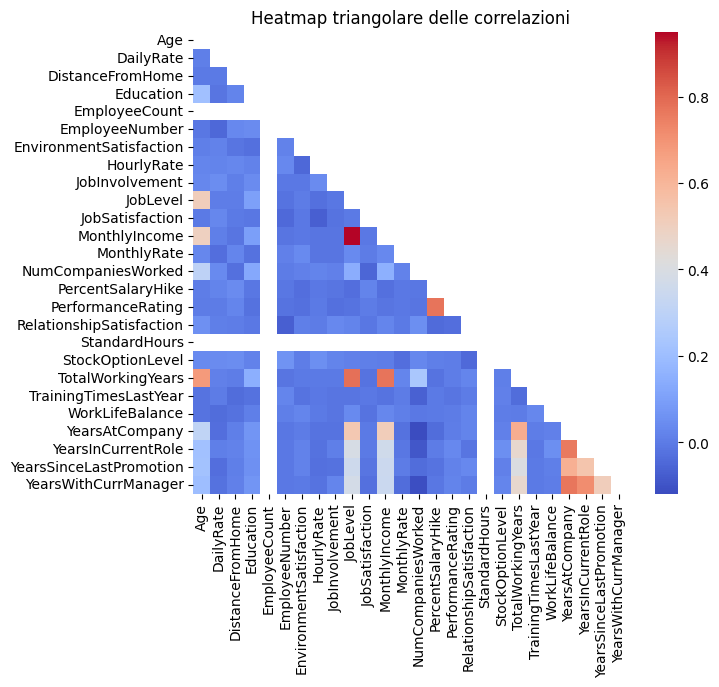

In [51]:
corr = emp.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(7,6))
sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    cmap="coolwarm",
)

plt.title("Heatmap triangolare delle correlazioni")
plt.show()

1. **La maggior parte delle correlazioni è debole**:
La heatmap è dominata da colori chiari, sia blu che rosati → significa che le variabili numeriche non sono fortemente correlate tra loro.

2. Ci sono alcune correlazioni moderate e attese  
Le zone più rosse (correlazioni positive più forti) sono:

* MonthlyIncome ↔ JobLevel  
Molto coerente: livelli di lavoro più alti → stipendi più alti.

* TotalWorkingYears ↔ YearsAtCompany  
Chi ha più anni di esperienza tende ad avere più anni in azienda.

* Age ↔ TotalWorkingYears  
Più età → più anni di lavoro.

* YearsAtCompany ↔ YearsInCurrentRole / YearsWithCurrManager  
Anche questo è naturale: chi è in azienda da più tempo tende ad avere più anni nel ruolo o con lo stesso manager.




**Commento sintetico**
La heatmap triangolare mostra che le correlazioni tra le variabili numeriche sono generalmente deboli. Le relazioni più evidenti sono quelle attese tra MonthlyIncome e JobLevel, tra TotalWorkingYears e YearsAtCompany, e tra Age e TotalWorkingYears.

*2. La distanza da casa influenza l'attrition?*

/tmp/ipykernel_1378/177085885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=emp, x='Attrition', y='DistanceFromHome', palette='Set2')


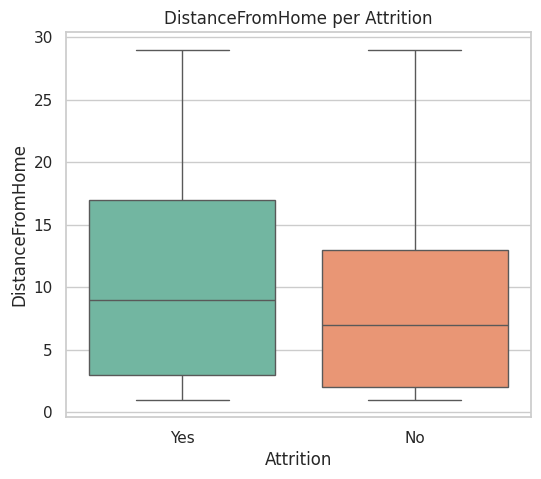

In [111]:
plt.figure(figsize=(6,5))
sns.boxplot(data=emp, x='Attrition', y='DistanceFromHome', palette='Set2')
plt.title('DistanceFromHome per Attrition')
plt.show()


Il boxplot mostra che i dipendenti che hanno lasciato l’azienda vivono mediamente più lontano dal luogo di lavoro. La mediana della distanza è più alta nel gruppo “Yes” e la distribuzione è più ampia, con valori più elevati nel 75° percentile. Questo suggerisce che una maggiore distanza da casa può essere associata a una maggiore propensione all’attrition, probabilmente per via di tempi e costi di spostamento più elevati. Il boxplot mostra un’associazione, non una relazione causale: vivere più lontano è correlato a maggiore attrition, ma non necessariamente la causa diretta.


*3.Il reddito influisce sull’attrition? E questo effetto è diverso tra uomini e donne?*

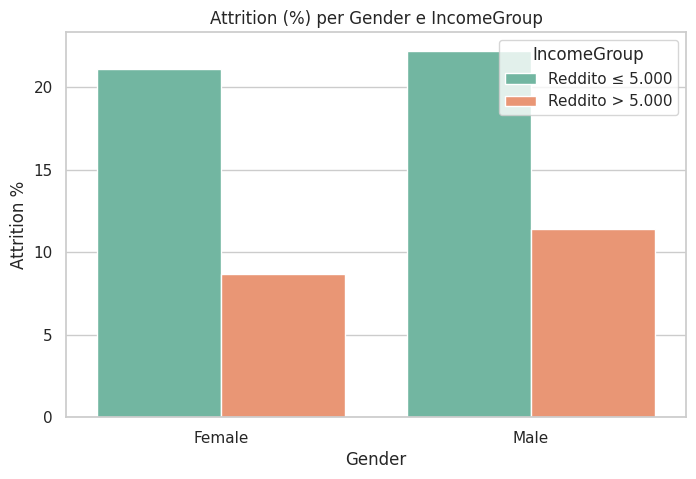

In [110]:
# Tabella percentuali Attrition per Gender × IncomeGroup
tab_attr = pd.crosstab(
    [emp['Gender'], emp['IncomeGroup']],
    emp['Attrition'],
    normalize='index'
).round(3) * 100

# Prendiamo solo la colonna Attrition = Yes
tab_plot = tab_attr['Yes'].reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=tab_plot,
    x='Gender',
    y='Yes',
    hue='IncomeGroup',
    palette='Set2'
)
plt.title('Attrition (%) per Gender e IncomeGroup')
plt.ylabel('Attrition %')
plt.show()


Il grafico conferma che il reddito è fortemente associato all’attrition: sia tra le donne sia tra gli uomini, la fascia di reddito ≤ 5.000 presenta percentuali di attrition nettamente più elevate rispetto alla fascia > 5.000. Le differenze tra generi sono minime: a parità di reddito, uomini e donne mostrano livelli di attrition molto simili.

Il grafico mostra un’associazione, non una relazione causale: il reddito è correlato all’attrition, ma non necessariamente la causa diretta.

*4. La distribuzione del reddito varia in modo significativo tra chi lascia e chi resta, nelle diverse fasce d’età?*

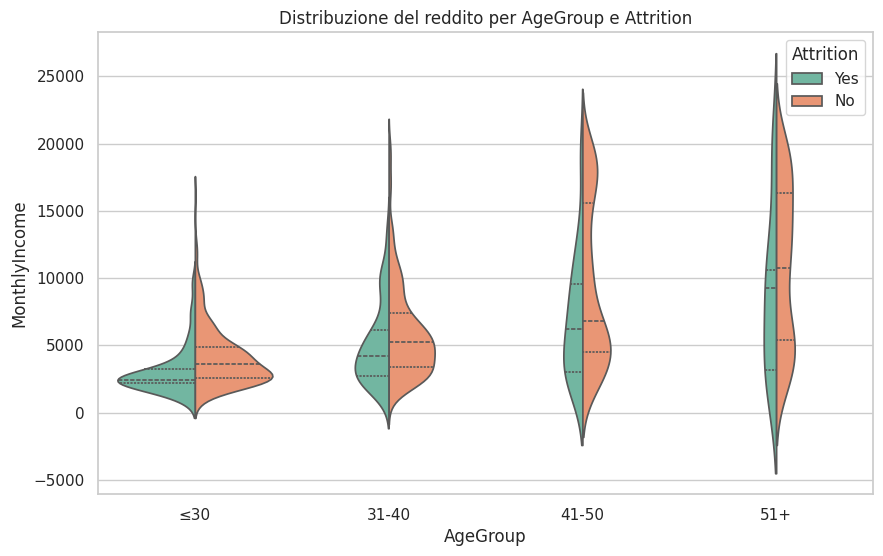

In [109]:
plt.figure(figsize=(10,6))
sns.violinplot(
    data=emp,
    x='AgeGroup',
    y='MonthlyIncome',
    hue='Attrition',
    palette='Set2',
    split=True,
    inner='quartile'   # linee più sottili e leggibili
)
plt.title('Distribuzione del reddito per AgeGroup e Attrition')
plt.show()

Il violin plot mostra che la distribuzione del reddito differisce nettamente tra i dipendenti che hanno lasciato l’azienda e quelli che sono rimasti, in tutte le fasce d’età. In ogni AgeGroup, il reddito dei dipendenti con Attrition = No risulta più elevato e presenta una distribuzione più ampia, con code che raggiungono valori molto alti. Al contrario, i dipendenti che hanno lasciato l’azienda mostrano distribuzioni più concentrate verso redditi medio-bassi. Le differenze diventano particolarmente evidenti nelle fasce 41–50 e 51+, dove i redditi più alti sono associati quasi esclusivamente al gruppo “No”. Questo suggerisce che il reddito è un fattore rilevante nella propensione all’attrition, con una maggiore stabilità tra i dipendenti con retribuzioni più elevate.

Questo risultato suggerisce che l’interazione tra età e reddito potrebbe essere rilevante nei modelli predittivi, più del singolo effetto dell’età.


*5. La distribuzione del reddito varia in modo sistematico tra i diversi JobLevel, e questa variazione è diversa tra chi lascia e chi resta?*

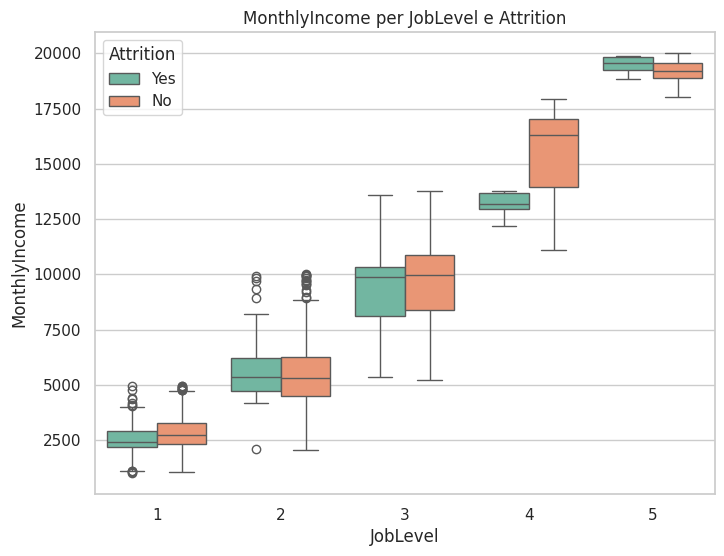

In [108]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=emp,
    x='JobLevel',
    y='MonthlyIncome',
    hue='Attrition',
    palette='Set2'
)
plt.title('MonthlyIncome per JobLevel e Attrition')
plt.show()


Il boxplot evidenzia una relazione chiara e coerente tra JobLevel e reddito: passando dai livelli più bassi a quelli più alti, la distribuzione del MonthlyIncome si sposta progressivamente verso valori maggiori e mostra una variabilità crescente.

In tutti i JobLevel, i dipendenti che non hanno lasciato l’azienda (Attrition = No) presentano redditi più elevati rispetto al gruppo Yes.

* Nei livelli più bassi (JobLevel 1 e 2), le distribuzioni dei due gruppi sono relativamente simili.

* Nei livelli più alti (JobLevel 4 e 5), i redditi elevati sono quasi esclusivamente associati al gruppo No, mentre il gruppo Yes rimane concentrato su valori medio‑bassi.

Il reddito cresce in modo sistematico con il JobLevel e i dipendenti con retribuzioni più elevate tendono a rimanere in azienda. Questo suggerisce una possibile relazione tra seniority, reddito e stabilità, con un effetto dell’attrition più marcato nei livelli professionali superiori.

*6. Esiste una relazione tra esperienza lavorativa (TotalWorkingYears) e reddito (MonthlyIncome)? E questa relazione differisce tra chi lascia e chi resta?*


**ho provato diversi scatterplot, ma nessuni mi convince pienamente, questo mi sembrava il meno peggio**


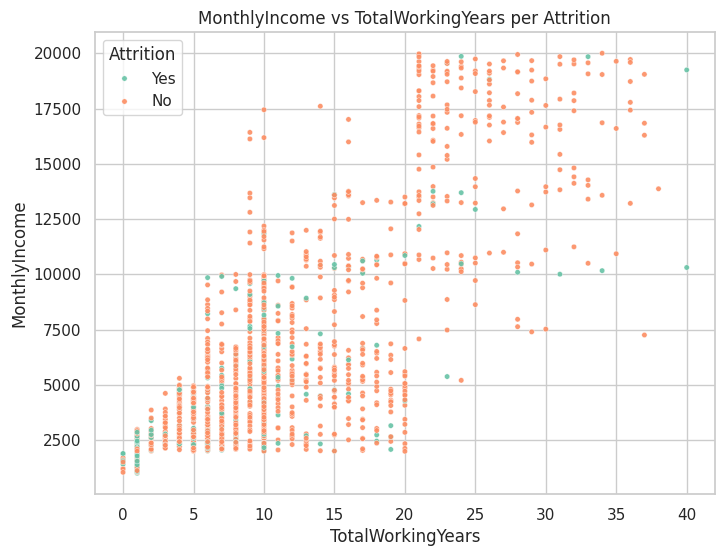

In [107]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=emp,
    x='TotalWorkingYears',
    y='MonthlyIncome',
    hue='Attrition',
    palette='Set2',
    s = 15,
    alpha=0.9
)
plt.title('MonthlyIncome vs TotalWorkingYears per Attrition')
plt.xlabel('TotalWorkingYears')
plt.ylabel('MonthlyIncome')
plt.show()


Lo scatterplot mostra una relazione positiva tra TotalWorkingYears e MonthlyIncome: i dipendenti con più anni di esperienza tendono ad avere redditi più elevati. La nuvola dei punti si inclina verso l’alto, indicando un aumento progressivo del reddito con l’esperienza.

Colorando i punti per Attrition, emerge un pattern chiaro:

i dipendenti che restano (Attrition = No) sono concentrati nelle zone con redditi più alti e maggiore esperienza;

i dipendenti che lasciano (Attrition = Yes) si trovano soprattutto nelle aree con redditi più bassi e pochi anni di esperienza.

Non si osservano dipendenti con attrition “Yes” nelle zone di reddito molto elevato, mentre queste aree sono popolate quasi esclusivamente dal gruppo “No”.

*7. manca domanda*

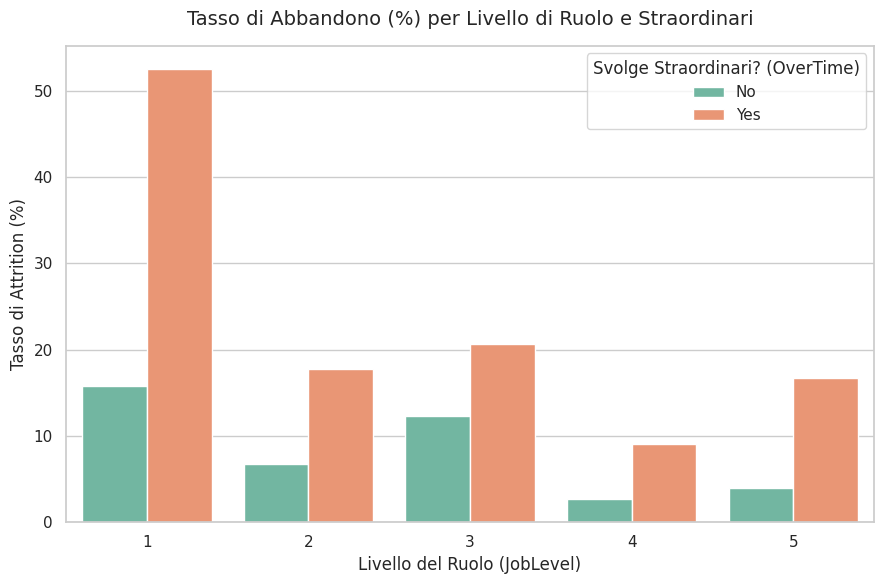

In [101]:
# 1. Calcoliamo le percentuali di Attrition per ogni combinazione di JobLevel e OverTime
confronto_classi = emp.groupby(['JobLevel', 'OverTime'])['Attrition'].value_counts(normalize=True).rename('Percentuale').reset_index()
confronto_classi['Percentuale'] *= 100

# 2. Filtriamo per tenere solo i casi in cui i dipendenti hanno lasciato l'azienda (Attrition == 'Yes')
dati_grafico = confronto_classi[confronto_classi['Attrition'] == 'Yes']

# 3. Creazione del grafico
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=dati_grafico,
    x='JobLevel',
    y='Percentuale',
    hue='OverTime',
    palette='Set2'
)

# Personalizzazione dei dettagli del grafico
plt.title('Tasso di Abbandono (%) per Livello di Ruolo e Straordinari', fontsize=14, pad=15)
plt.xlabel('Livello del Ruolo (JobLevel)', fontsize=12)
plt.ylabel('Tasso di Attrition (%)', fontsize=12)
plt.legend(title='Svolge Straordinari? (OverTime)')

# Salvataggio dell'immagine (opzionale per la cartella figures/)
plt.tight_layout()
plt.savefig('confronto_classi_joblevel_overtime.png', dpi=300)
plt.show()

Cosa mostra: Il grafico visualizza il tasso di abbandono (Attrition = Yes) segmentato per l'inquadramento contrattuale (da 1 a 5) e per la presenza di ore straordinarie.
Evidenza principale: La colonna arancione del JobLevel 1 (profili junior che fanno straordinari) svetta nettamente sulle altre, confermando che il sovraccarico di lavoro ha un impatto distruttivo e sproporzionato soprattutto sulle figure all'inizio della propria carriera aziendale.

*8. manca domanda*

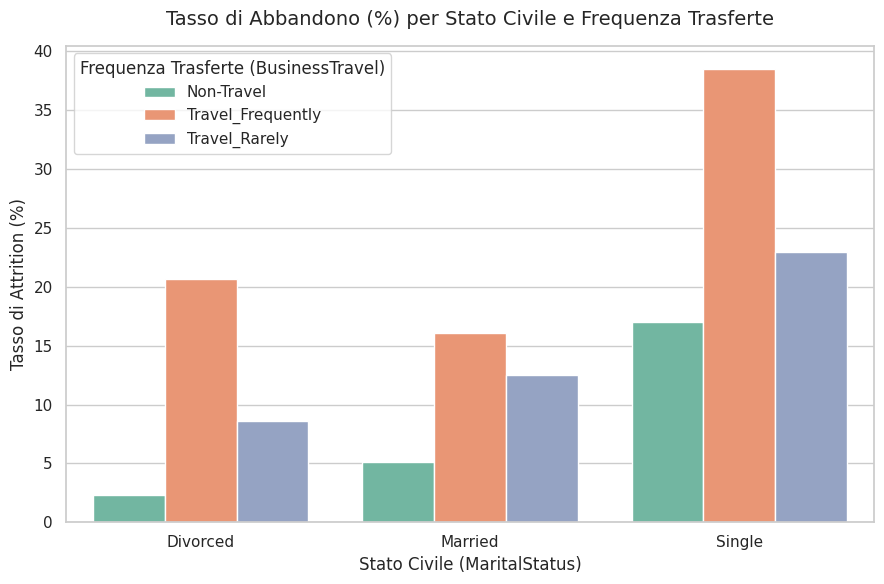

In [102]:
# 1. Calcoliamo le percentuali di Attrition per ogni combinazione di MaritalStatus e BusinessTravel
confronto_classi_2 = emp.groupby(['MaritalStatus', 'BusinessTravel'])['Attrition'].value_counts(normalize=True).rename('Percentuale').reset_index()
confronto_classi_2['Percentuale'] *= 100

# 2. Filtriamo per tenere solo i casi in cui i dipendenti hanno lasciato l'azienda (Attrition == 'Yes')
dati_grafico_2 = confronto_classi_2[confronto_classi_2['Attrition'] == 'Yes']

# 3. Creazione del grafico
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=dati_grafico_2,
    x='MaritalStatus',
    y='Percentuale',
    hue='BusinessTravel',
    palette='Set2'
)

# Personalizzazione dei dettagli del grafico
plt.title('Tasso di Abbandono (%) per Stato Civile e Frequenza Trasferte', fontsize=14, pad=15)
plt.xlabel('Stato Civile (MaritalStatus)', fontsize=12)
plt.ylabel('Tasso di Attrition (%)', fontsize=12)
plt.legend(title='Frequenza Trasferte (BusinessTravel)')

plt.tight_layout()
plt.savefig('confronto_classi_marital_travel.png', dpi=300)
plt.show()

Questo confronto incrocia lo stato civile (MaritalStatus: Single, Sposato, Divorziato) con la frequenza delle trasferte di lavoro (BusinessTravel). Il grafico mostra che il tasso di abbandono più alto in assoluto si registra tra i dipendenti Single che viaggiano frequentemente (Travel_Frequently), seguiti subito dopo dai dipendenti sposati che viaggiano molto. In generale, chi non viaggia mai (Non-Travel) mostra livelli minimi di Attrition in qualsiasi categoria.
Conclusione: L'obbligo di trasferte frequenti agisce come un forte acceleratore del turnover, ma il fenomeno è amplificato dallo stato civile: i profili Single che viaggiano molto rappresentano la combinazione più instabile e a rischio per l'azienda

# Fase 4 - Modellazione
* Confrontare modelli diversi
* Minimo: 3 modelli, di cui almeno 1 lineare (es. regressione) e 1 non lineare (es. kNN, Random Forest)

NB. train/test split e codifica delle variabili categoriche a nostro carico

EmployeeCount, Over18 e StandardHours hanno sempre lo stesso valore; non aggiungono nessuna informazione utile: si possono rimuovere.

In [ ]:
emp.drop(columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'])
#Employee Number è solo l'identificativo del dipendente, quindi possiamo rimuoverlo

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomeGroup,AgeGroup
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,8,0,1,6,4,0,5,Reddito > 5.000,41-50
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1,10,3,3,10,7,1,7,Reddito > 5.000,41-50
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,7,3,3,0,0,0,0,Reddito ≤ 5.000,31-40
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,8,3,3,8,7,3,0,Reddito ≤ 5.000,31-40
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,1,6,3,3,2,2,2,2,Reddito ≤ 5.000,≤30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,1,17,3,3,5,2,0,3,Reddito ≤ 5.000,31-40
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,1,9,5,3,7,7,1,7,Reddito > 5.000,31-40
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,1,6,0,3,6,2,0,3,Reddito > 5.000,≤30
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,0,17,3,2,9,6,0,8,Reddito > 5.000,41-50


Abbiamo rimosso le colonne che hanno un solo valore nel dataset, perchè non forniscono informazione per i modelli predittivi. La variabile EmployeeNumber è un identificativo univoco del dipendente e non è utile per l'obiettivo di prevedere l'attrition.

In [98]:
X = emp[["TotalWorkingYears"]]   # input: deve essere una matrice / DataFrame
y = emp["MonthlyIncome"]     # output: può essere una Series (coppie chaive valore: prova a prevedere se tu studi tot, prendi tot)
#x= ore y= voti

lin_model = LinearRegression() #modello SVM
lin_model.fit(X, y) #fit = serve per apprendere
#così apprende e calcola la retta

a = lin_model.coef_[0] # coef = coefficiente angolare (prendenza della retta)
b = lin_model.intercept_

a, b
#risultato regressione lineare: y= 1.07x + 18.34
#quindi se uno studente ha studiato 5 ore (x= 5) --> allora y= 24

(np.float64(467.65841184883016), np.float64(1227.9352878466307))

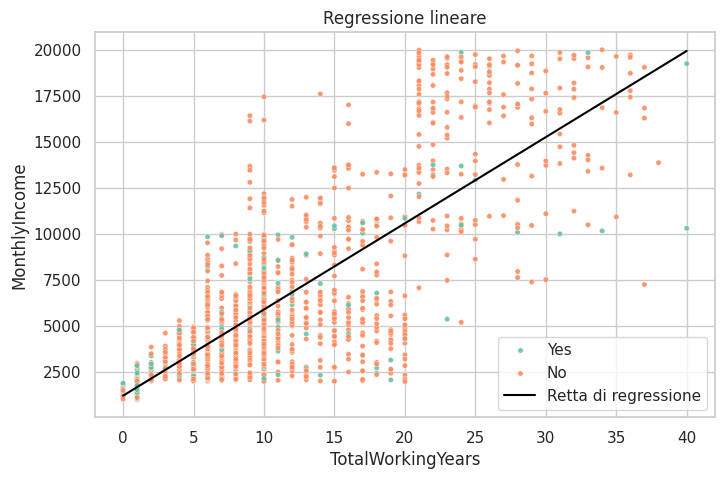

In [106]:
x_line = np.linspace(emp["TotalWorkingYears"].min(), emp["TotalWorkingYears"].max(), 100)
y_line = lin_model.predict(pd.DataFrame({"TotalWorkingYears": x_line}))

plt.figure(figsize=(8, 5))

# scatterplot con distinzione per Attrition
sns.scatterplot(
    data=emp,
    x="TotalWorkingYears",
    y="MonthlyIncome",
    hue="Attrition",      # <--- qui!
    palette='Set2',
    s = 15,
    alpha=0.9
)

# retta di regressione (senza hue)
plt.plot(x_line, y_line, color="black", label="Retta di regressione")

plt.title("Regressione lineare")
plt.xlabel("TotalWorkingYears")
plt.ylabel("MonthlyIncome")
plt.legend()
plt.show()


# Fase 5 - Valutazione e interpretazione dei risultati
* Per ogni modello: accuracy, confusion matrix, precision, recall, f1-score
* Riflessioni: punti di forza, limiti, interpretabilità, tipo di errori, costo computazionale
* Approfondimenti possibili: feature importance (RF), coefficienti (regressione logistica)

**CONCLUSIONI: AGGIUNGERE CHE I PATTERN NON CORRISPONDONO A CAUSALITà (E CHE IL DATASET PUò AVERE BIAS ORGANIZZATIVI)........**

# Fase 6 - Report scientifico in LaTeX (Overleaf)
* Lunghezza indicativa: ~6 pagine
* Caricare su GitHub (cartella report/ ) sia il PDF finale che tutti i sorgenti Overleaf (file .tex, immagini, bibliografia, ecc.)
* Sezioni tipiche: Introduzione, Dataset, Metodologia, Risultati, Discussione, Conclusioni
* Elementi obbligatori: ≥2 figure, ≥1 tabella, ≥1 formula, bibliografia, link al repository GitHub